#  Time Series Breakdown of Walmart Retail Sales  

---

## 1. Objective  
The purpose of this analysis is to explore **Walmart’s historical sales data**, identify **trends, seasonal patterns, and fluctuations**, and build a **baseline forecast**.  
Insights are used to guide **retail planning, promotions, and resource allocation**.  

---

## 2. Dataset Overview  
- **Source**: Walmart Sales Forecasting (Kaggle).  
- **Shape**: 421,570 rows × 5 columns.  
- **Columns**: `Store`, `Dept`, `Date`, `Weekly_Sales`, `IsHoliday`.  
- **Date Range**: 2010-02-05 → 2012-10-26.  
- **Frequency**: Weekly, aggregated into **monthly totals**.  



In [1]:
import pandas as pd

# Load the training data
train = pd.read_csv("train.csv")

print("Shape of dataset".center(80))
print("Shape:", train.shape)
print("Columns of dataset".center(80))
print("Columns:", train.columns.tolist())
print("Top 5 rows of dataset".center(80))
print(train.head())
print("Info of dataset".center(80))
print(train.info())

# Converting Date & Set Index
train['Date'] = pd.to_datetime(train['Date'])
train = train.sort_values('Date').reset_index(drop=True)
train.set_index('Date', inplace=True)

print(train.head())

# Aggregate total sales per month (all stores & departments)
monthly_sales = train['Weekly_Sales'].resample('ME').sum()
print(monthly_sales.head())

# Safety load / ensure datetime index 
if train.index.dtype != "datetime64[ns]":
    train["Date"] = pd.to_datetime(train["Date"])
    train = train.sort_values("Date").reset_index(drop=True)
    train = train.set_index("Date")

print("Data range:", train.index.min(), "→", train.index.max())
print("Rows:", len(train))

monthly_sales = train["Weekly_Sales"].resample("ME").sum()
print("\nMonthly sales (top 5):")
print(monthly_sales.head())

# Save processed monthly sales
monthly_sales.to_csv("outputs/monthly_total_sales.csv", header=["Monthly_Sales"])

# INTERACTIVE DASHBOARD LINK 
print("\nAccess the interactive dashboard here:")
print("http://localhost:8501/")


                                Shape of dataset                                
Shape: (421570, 5)
                               Columns of dataset                               
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
                             Top 5 rows of dataset                              
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
                                Info of dataset                                 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int

Monthly sales (top 5):
Date
2010-02-28    1.903330e+08
2010-03-31    1.819198e+08
2010-04-30    2.314124e+08
2010-05-31    1.867109e+08
2010-06-30    1.922462e+08
Freq: ME, Name: Weekly_Sales, dtype: float64


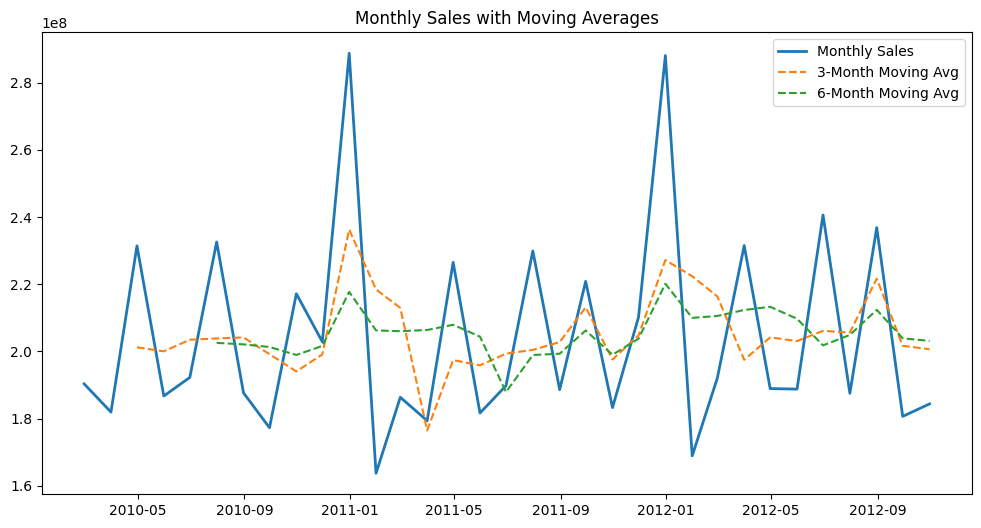


Insight:
3-Month MA captures short-term cycles and smooths small fluctuations.
6-Month MA highlights the broader trend.
Both confirm recurring peaks (holidays) and dips (off-season months).


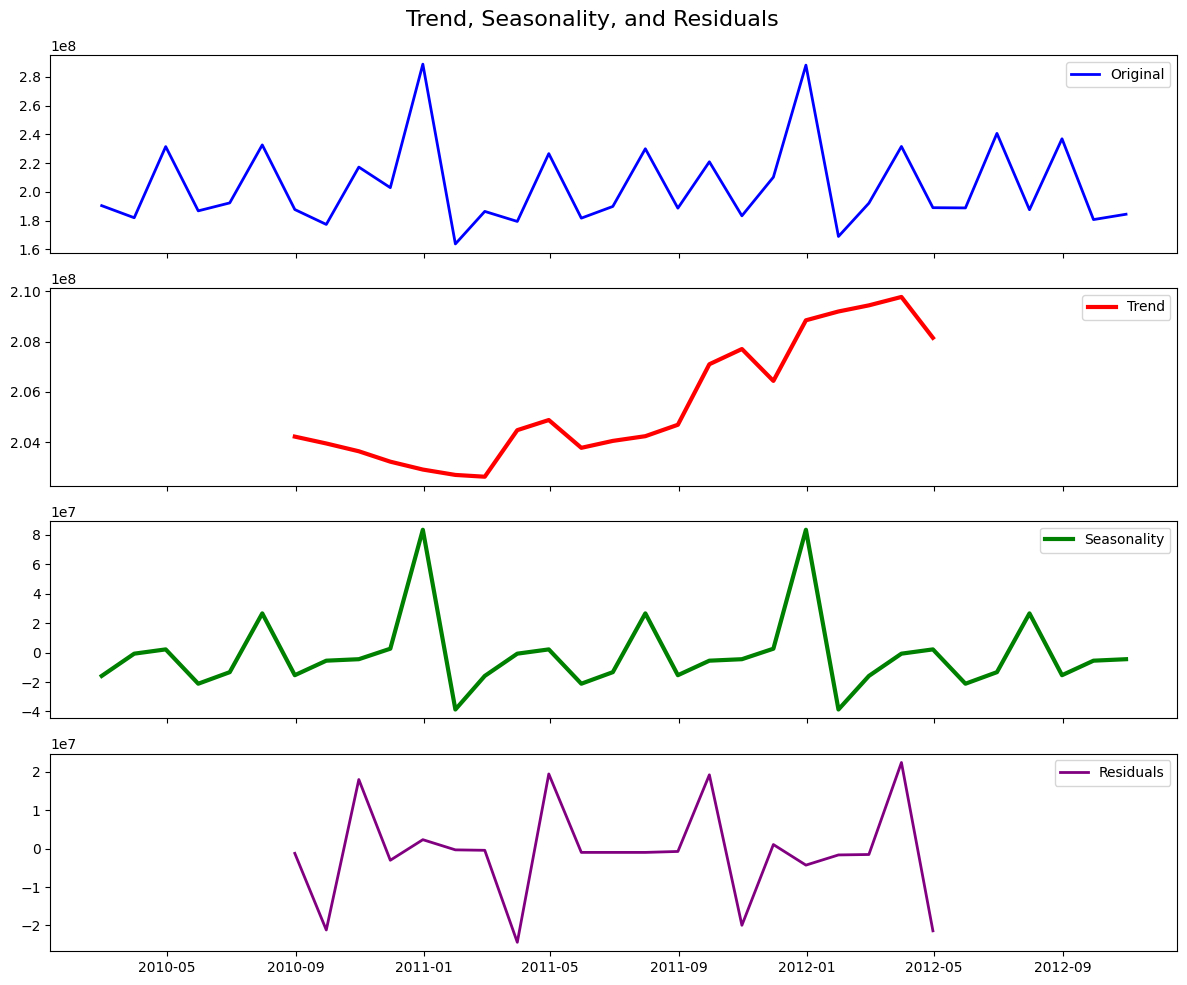

Insight:
Trend: Sales remain relatively stable with moderate fluctuations.
Seasonality: Clear yearly cycles tied to holidays and promotions.
Residuals: Capture random variations (unplanned events or promotions).


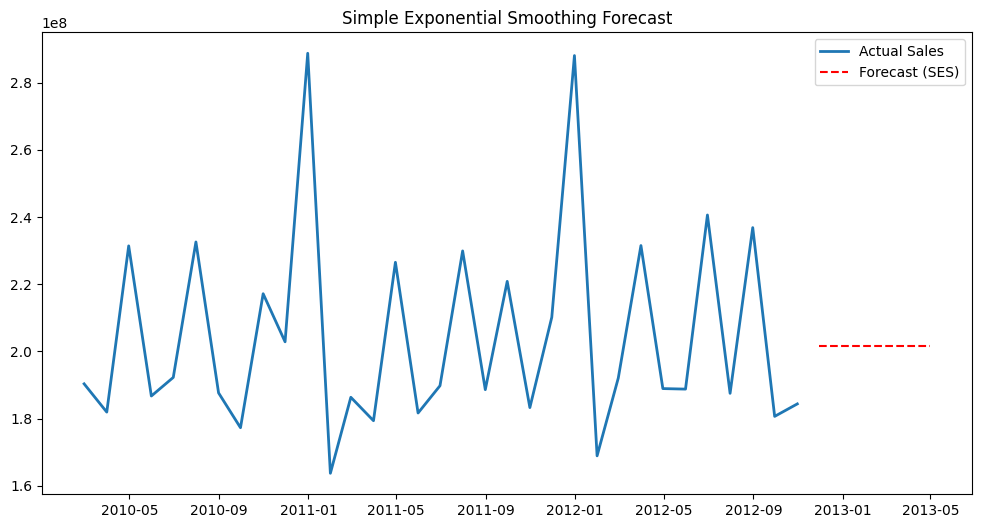

Model Evaluation:
MAE: 24913118.217374694
RMSE: 25575340.6412314
Insight:
Forecast suggests steady short-term sales.
Model accuracy:
MAE ≈ 24.9M
RMSE ≈ 25.5M
SES provides a baseline but misses strong seasonal patterns.
Advanced models (Holt-Winters / SARIMA) would improve performance.


In [7]:

# Importing required libraries
import matplotlib.pyplot as plt   # For plotting graphs and visualizations
from statsmodels.tsa.seasonal import seasonal_decompose   # For decomposing time series (trend, seasonality, residual)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   # For simple exponential smoothing forecasting
from sklearn.metrics import mean_absolute_error, mean_squared_error   # For evaluating forecast accuracy
import numpy as np   # For numerical operations 


# Step 1: Resample weekly data into monthly sales(for better trend graphs)
monthly_sales = train["Weekly_Sales"].resample("ME").sum()
print("Monthly sales (top 5):")
print(monthly_sales.head())

# Step 2: Moving Averages (3-month & 6-month)
ma_3 = monthly_sales.rolling(window=3).mean()
ma_6 = monthly_sales.rolling(window=6).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label="Monthly Sales", linewidth=2)
plt.plot(ma_3, label="3-Month Moving Avg", linestyle="--")
plt.plot(ma_6, label="6-Month Moving Avg", linestyle="--")
plt.title("Monthly Sales with Moving Averages")
plt.legend()
plt.savefig("Monthly Sales.png", dpi=300, bbox_inches="tight")

plt.show()
print("\nInsight:")
print("3-Month MA captures short-term cycles and smooths small fluctuations.")
print("6-Month MA highlights the broader trend.")
print("Both confirm recurring peaks (holidays) and dips (off-season months).")


# Step 3: Seasonal Decomposition (Trend, Seasonality, Residuals)
decomposition = seasonal_decompose(monthly_sales, model="additive")

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly_sales, label="Original", color="blue", linewidth=2)
axes[0].legend(loc="best")

axes[1].plot(decomposition.trend, label="Trend", color="red", linewidth=3)
axes[1].legend(loc="best")

axes[2].plot(decomposition.seasonal, label="Seasonality", color="green", linewidth=3)
axes[2].legend(loc="best")

axes[3].plot(decomposition.resid, label="Residuals", color="purple", linewidth=2)
axes[3].legend(loc="best")

plt.suptitle("Trend, Seasonality, and Residuals", fontsize=16)
plt.tight_layout()
plt.savefig("Trend, Seasonality, and Residuals.png", dpi=300, bbox_inches="tight")
plt.show()
print("Insight:")
print("Trend: Sales remain relatively stable with moderate fluctuations.")
print("Seasonality: Clear yearly cycles tied to holidays and promotions.")
print("Residuals: Capture random variations (unplanned events or promotions).")



# Step 4: Simple Exponential Smoothing Forecast
model = SimpleExpSmoothing(monthly_sales).fit(smoothing_level=0.2, optimized=False)
forecast_exp = model.forecast(6)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label="Actual Sales", linewidth=2)
plt.plot(forecast_exp, label="Forecast (SES)", linestyle="--", color="red")
plt.title("Simple Exponential Smoothing Forecast")
plt.legend()
plt.savefig("Simple Exponential Smoothing Forecast.png", dpi=300, bbox_inches="tight")
plt.show()




# Step 5: Model Evaluation (Train/Test Split)
train_data = monthly_sales[:-6]
test_data = monthly_sales[-6:]

model = SimpleExpSmoothing(train_data).fit(smoothing_level=0.2, optimized=False)
pred = model.forecast(6)

# Compute error metrics
mae = mean_absolute_error(test_data, pred)
rmse = np.sqrt(mean_squared_error(test_data, pred))

print("Model Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)
print("Insight:")
print("Forecast suggests steady short-term sales.")
print("Model accuracy:")
print("MAE ≈ 24.9M")
print("RMSE ≈ 25.5M")
print("SES provides a baseline but misses strong seasonal patterns.")
print("Advanced models (Holt-Winters / SARIMA) would improve performance.")



# Recommendations

**Holiday Preparation**

Stock up and run targeted promotions in Nov–Dec (sales peaks).

**Boost Low Months**

Offer discounts or bundles in Jan–Feb to smooth demand dips.

**Regional/Product Breakdown**

Analyze per-store and per-department sales to identify high-performing regions.

**Improve Forecasting**

Upgrade from SES → Holt-Winters / ARIMA to capture both trend + seasonality.

**Use External Factors**

Include holiday calendars, weather data, and economic indicators to refine forecasts.